In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter

import numpy as np
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/advanced_mech2/lab2/Step_Response_1V_PP.csv") # second, Volt
df3 = pd.read_csv("/content/drive/MyDrive/advanced_mech2/lab2/scope_21.csv")
df5 = pd.read_csv("/content/drive/MyDrive/advanced_mech2/lab2/scope_22.csv")
df6 = pd.read_csv("/content/drive/MyDrive/advanced_mech2/lab2/scope_23.csv")

In [ ]:
df1.drop(labels=0, axis=0, inplace = True)
df1

,x-axis,1,2
1,-1.00E-02,-2.51E-01,-5.23E-02
2,-9.98E-03,-2.54E-01,-4.96E-02
3,-9.96E-03,-2.51E-01,-5.23E-02
4,-9.94E-03,-2.54E-01,-5.23E-02
5,-9.92E-03,-2.51E-01,-5.23E-02
...,...,...,...
996,9.90E-03,2.44E-01,4.70E-02
997,9.92E-03,2.44E-01,4.96E-02
998,9.94E-03,2.44E-01,4.96E-02
999,9.96E-03,2.48E-01,4.70E-02


In [ ]:

df1['x-axis'] = df1['x-axis'].astype(float)
df1['1'] = df1['1'].astype(float)
df1['2'] = df1['2'].astype(float)


In [ ]:

df3['in'] = df3['in'].astype(float)
df3['out'] = df3['out'].astype(float)

df5['x-axis'] = df5['x-axis'].astype(float)
df5['in'] = df5['in'].astype(float)
df5['out'] = df5['out'].astype(float)

df6['x-axis'] = df6['x-axis'].astype(float)
df6['in'] = df6['in'].astype(float)
df6['out'] = df6['out'].astype(float)


In [ ]:
time1 =  np.array(df1['x-axis'])
time3 =  np.array(df3['x-axis'])
time5 =  np.array(df5['x-axis'])
time6 =  np.array(df6['x-axis'])

input1 = np.array(df1['1'])
input3 = np.array(df3['in'])
input5 = np.array(df5['in'])
input6 = np.array(df6['in'])

output1 = np.array(df1['2']) /2
output3 = np.array(df3['out']) /2 
output5 = np.array(df5['out']) /2 
output6 = np.array(df6['out']) /2 



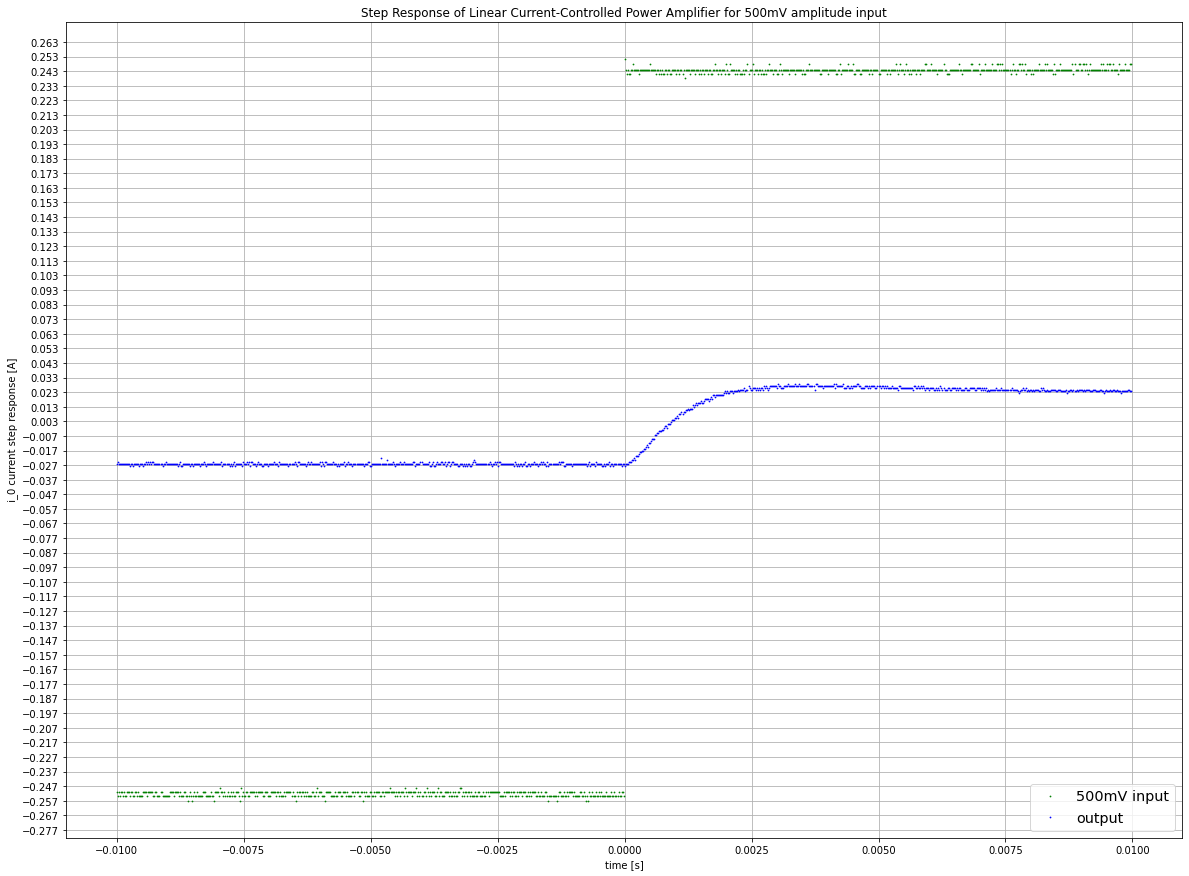

In [ ]:

fig1 = plt.figure(figsize = (20,15))
plt.xlabel('time [s]')
plt.ylabel(' i_0 current step response [A]')
plt.title('Step Response of Linear Current-Controlled Power Amplifier for 500mV amplitude input')
plt.grid()
#plt.autoscale(enable=True, axis='both', tight=None)
plt.yticks(np.arange(min(input1) - 0.02, max(input1) + 0.02, step=0.01))  # Set label locations.
#plt.xticks(np.arange(min(time1) - 0.01, max(time1) + 0.01, step=0.001))

plt.plot(time1,input1,'g.', label = '500mV input', markersize = 1.5)
plt.plot(time1,output1,'b.',label = 'output', markersize = 1.5)

plt.legend(loc = 'lower right',fontsize="x-large") # using a named size




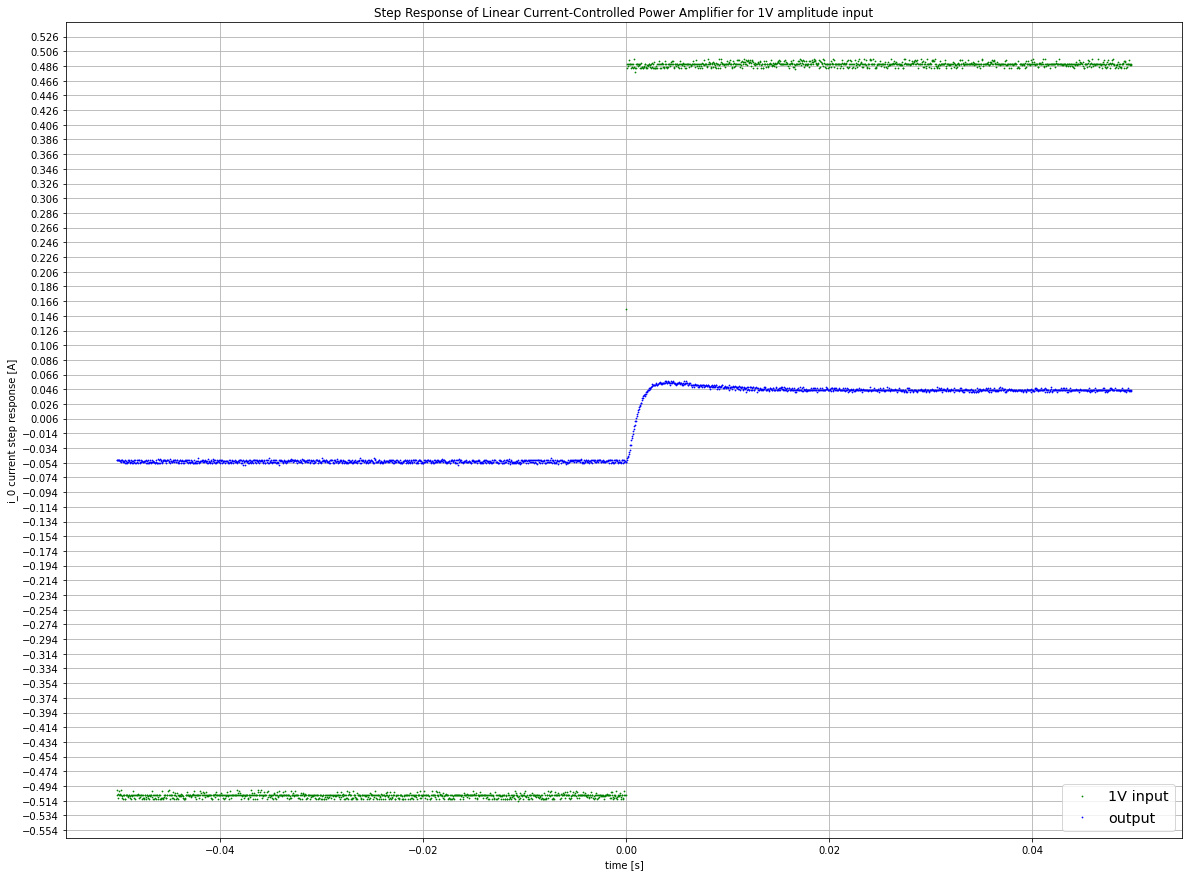

In [ ]:


fig3 = plt.figure(figsize = (20,15))
plt.xlabel('time [s]')
plt.ylabel('i_0 current step response [A]')
plt.title('Step Response of Linear Current-Controlled Power Amplifier for 1V amplitude input')
plt.grid()
#plt.autoscale(enable=True, axis='both', tight=None)
plt.yticks(np.arange(min(input3) - 0.1, max(input3) + 0.1, step=0.02))  # Set label locations.
#plt.xticks(np.arange(min(time3) - 0.01, max(time3) + 0.01, step=0.005))


plt.plot(time3,input3,'g.', label = '1V input', markersize = 1.5)
plt.plot(time3,output3,'b.',label = 'output', markersize = 1.5)

plt.legend(loc = 'lower right',fontsize="x-large") # using a named size


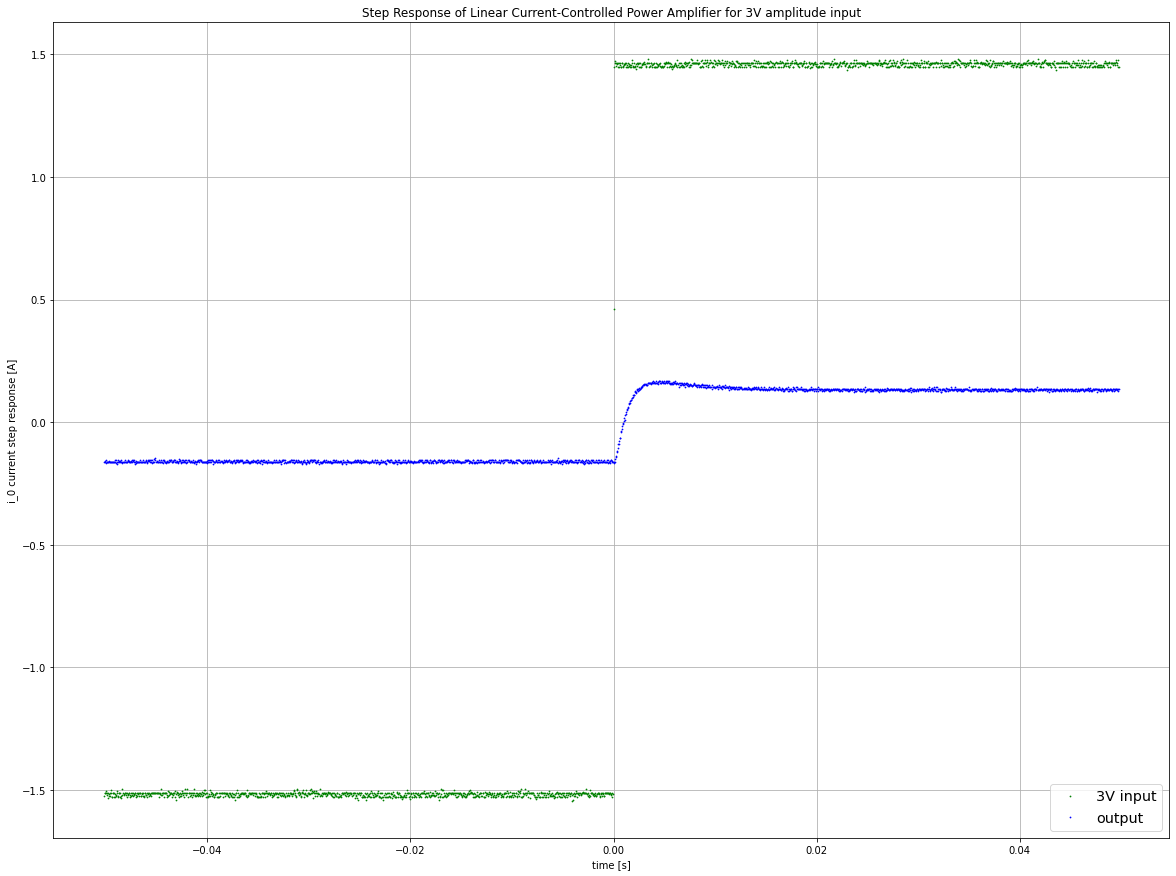

In [ ]:

fig5 = plt.figure(figsize = (20,15))
plt.xlabel('time [s]')
plt.ylabel('i_0 current step response [A]')
plt.title('Step Response of Linear Current-Controlled Power Amplifier for 3V amplitude input')
plt.grid()
plt.autoscale(enable=True, axis='both', tight=None)
#plt.yticks(np.arange(min(input5) - 0.1, max(input5) + 0.1, step=0.1))  # Set label locations.
#plt.xticks(np.arange(min(time5) - 0.01, max(time5) + 0.01, step=0.005))

plt.plot(time5,input5,'g.', label = '3V input', markersize = 1.5)
plt.plot(time5,output5,'b.',label = 'output', markersize = 1.5)

plt.legend(loc = 'lower right',fontsize="x-large") # using a named size

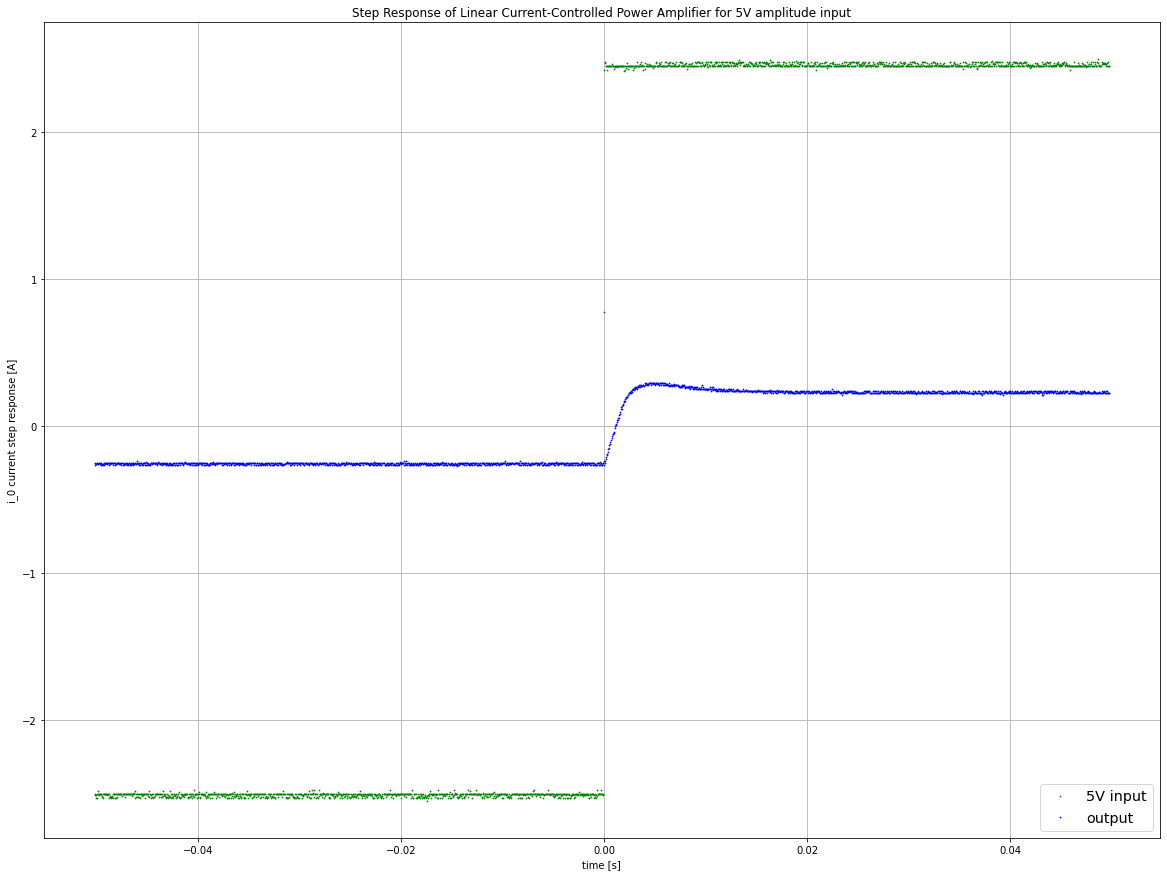

In [ ]:

fig1 = plt.figure(figsize = (20,15))
plt.xlabel('time [s]')
plt.ylabel('i_0 current step response [A]')
plt.title('Step Response of Linear Current-Controlled Power Amplifier for 5V amplitude input')
plt.grid()
plt.autoscale(enable=True, axis='both', tight=None)
#plt.yticks(np.arange(min(input6) - 0.1, max(input6) + 0.1, step=0.1))  # Set label locations.

plt.plot(time6,input6,'g.', label = '5V input', markersize = 1.5)
plt.plot(time6,output6,'b.',label = 'output', markersize = 1.5)

plt.legend(loc = 'lower right',fontsize="x-large") # using a named size

In [ ]:
from math import pi

max_val_output1 = max(output1)
output1_inf = output1[-1]
print('max:',max_val_output1)
print('steady state val:',output1_inf)
overshoot1 = (max_val_output1-output1_inf)/output1_inf
print('overshoot:',overshoot1)
damping_ratio1 = (1+(pi/np.log(overshoot1)**2))**(-0.5)
print('damping ratio:',damping_ratio1)

time1_beforePeak = time1[:np.argmax(output1)]
output1_beforePeak = output1[:np.argmax(output1)]
rise_time1 =  time1_beforePeak[np.absolute(output1_beforePeak-output1_inf).argmin()]
print('rise_time:',rise_time1)

omega_crossover1 = 1.8/rise_time1
print('crossover freq:',omega_crossover1)


max: 0.02875
steady state val: 0.0235
overshoot: 0.22340425531914898
damping ratio: 0.6456920755259573
rise_time: 0.00198
crossover freq: 909.0909090909091


In [ ]:
max_val_output3 = max(output3)
output3_inf = output3[-1]
print('max:',max_val_output3)
print('steady state val:',output3_inf)
overshoot3 = (max_val_output3-output3_inf)/output3_inf
print('overshoot:',overshoot3)
damping_ratio3 = (1+(pi/np.log(overshoot3)**2))**(-0.5)
print('damping ratio:',damping_ratio3)

time3_beforePeak = time3[:np.argmax(output3)]
output3_beforePeak = output3[:np.argmax(output3)]
rise_time3 =  time3_beforePeak[np.absolute(output3_beforePeak-output3_inf).argmin()]
print('rise_time:',rise_time3)

omega_crossover3 = 1.8/rise_time3
print('crossover freq:',omega_crossover3)

max: 0.0572865
steady state val: 0.045226
overshoot: 0.2666718259408304
damping ratio: 0.5977967053379389
rise_time: 0.00215
crossover freq: 837.2093023255815


In [ ]:
max_val_output5 = max(output5)
output5_inf = output5[-1]
print('max:',max_val_output5)
print('steady state val:',output5_inf)
overshoot5 = (max_val_output5-output5_inf)/output5_inf
print('overshoot:',overshoot5)
damping_ratio5 = (1+(pi/np.log(overshoot5)**2))**(-0.5)
print('damping ratio:',damping_ratio5)

time5_beforePeak = time5[:np.argmax(output5)]
output5_beforePeak = output5[:np.argmax(output5)]
rise_time5 =  time5_beforePeak[np.absolute(output5_beforePeak-output5_inf).argmin()]
print('rise_time:',rise_time5)

omega_crossover5 = 1.8/rise_time5
print('crossover freq:',omega_crossover5)

max: 0.168845
steady state val: 0.136685
overshoot: 0.23528551048030139
damping ratio: 0.6323907735408254
rise_time: 0.00245
crossover freq: 734.6938775510205


In [ ]:
max_val_output6 = max(output6)
output6_inf = output6[-1]
print('max:',max_val_output6)
print('steady state val:',output6_inf)
overshoot6 = (max_val_output6-output6_inf)/output6_inf
print('overshoot:',overshoot6)
damping_ratio6 = (1+(pi/np.log(overshoot6)**2))**(-0.5)
print('damping ratio:',damping_ratio6)

time6_beforePeak = time6[:np.argmax(output6)]
output6_beforePeak = output6[:np.argmax(output6)]
rise_time6 =  time6_beforePeak[np.absolute(output6_beforePeak-output6_inf).argmin()]
print('rise_time:',rise_time6)

omega_crossover6 = 1.8/rise_time6
print('crossover freq:',omega_crossover6)

max: 0.2954775
steady state val: 0.2251255
overshoot: 0.3125012493031664
damping ratio: 0.5486478601036634
rise_time: 0.0026
crossover freq: 692.3076923076924
